In [1]:
from IPython.display import Markdown
import torch
import string
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline

## data

In [2]:
with open("../data/usnames.txt", "r") as f:
    names = f.readlines()

In [3]:
Markdown(f"Number of names = {len(names)}")

Number of names = 32033

In [4]:
names = [n.strip() for n in names]

In [5]:
names[0]

'emma'

In [6]:
'\'' + names[np.argmax(np.array([len(n) for n in names])).item()] + '\' is the longest name'

"'muhammadibrahim' is the longest name"

In [7]:
'\'' + names[np.argmin(np.array([len(n) for n in names])).item()] + '\' is the shortest name'

"'an' is the shortest name"

## tokenize

In [8]:
tok2idx = {c: i for i, c in enumerate('.' + string.ascii_lowercase)}
idx2tok = {i: c for c, i in tok2idx.items()}

In [9]:
tok2idx

{'.': 0,
 'a': 1,
 'b': 2,
 'c': 3,
 'd': 4,
 'e': 5,
 'f': 6,
 'g': 7,
 'h': 8,
 'i': 9,
 'j': 10,
 'k': 11,
 'l': 12,
 'm': 13,
 'n': 14,
 'o': 15,
 'p': 16,
 'q': 17,
 'r': 18,
 's': 19,
 't': 20,
 'u': 21,
 'v': 22,
 'w': 23,
 'x': 24,
 'y': 25,
 'z': 26}

In [10]:
[(x, y) for x, y in zip('.emma', 'emma.')]

[('.', 'e'), ('e', 'm'), ('m', 'm'), ('m', 'a'), ('a', '.')]

## creating a count matrix

In [11]:
C = torch.zeros((len(tok2idx), len(tok2idx)))

for name in names:
    for c, nc in zip('.' + name, name+'.'):
        C[tok2idx[c]][tok2idx[nc]] += 1

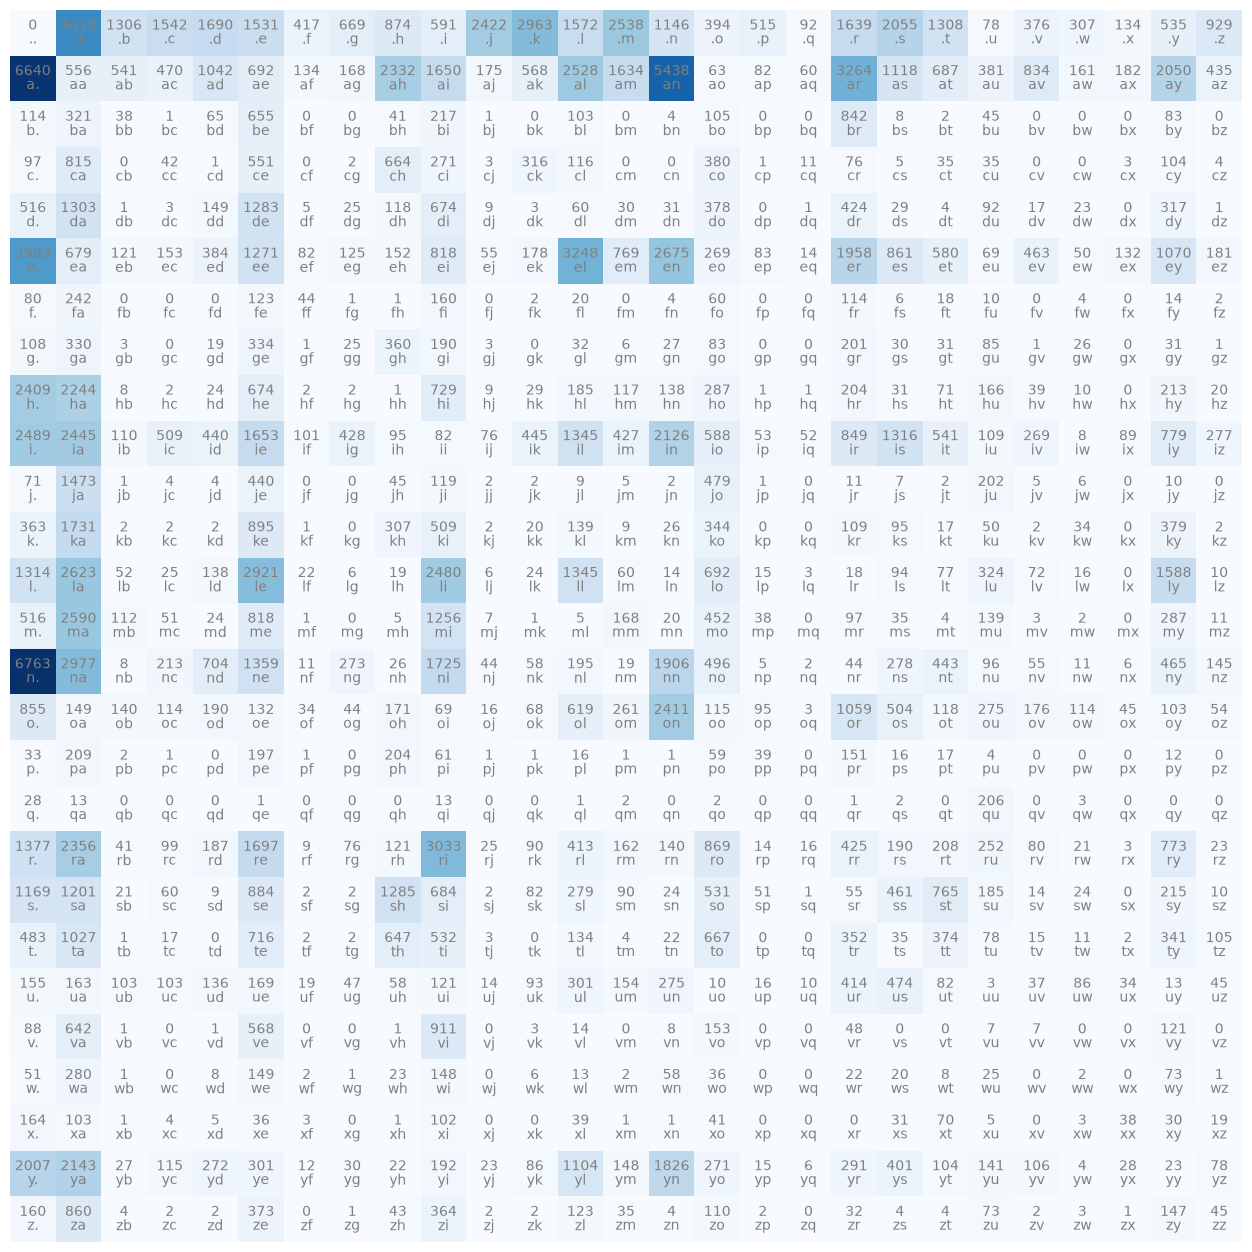

In [12]:
plt.figure(figsize=(16, 16)); plt.imshow(C, cmap="Blues")

for y in range(len(tok2idx)):
    for x in range(len(tok2idx)):
        label = idx2tok[y]+idx2tok[x]
        plt.text(x, y, label, ha="center", va="top", color="gray")
        plt.text(x, y, int(C[y][x]), ha="center", va="bottom", color="gray")
plt.axis('off');

In [13]:
P = C.float() / C.sum(axis=1, keepdim=True)

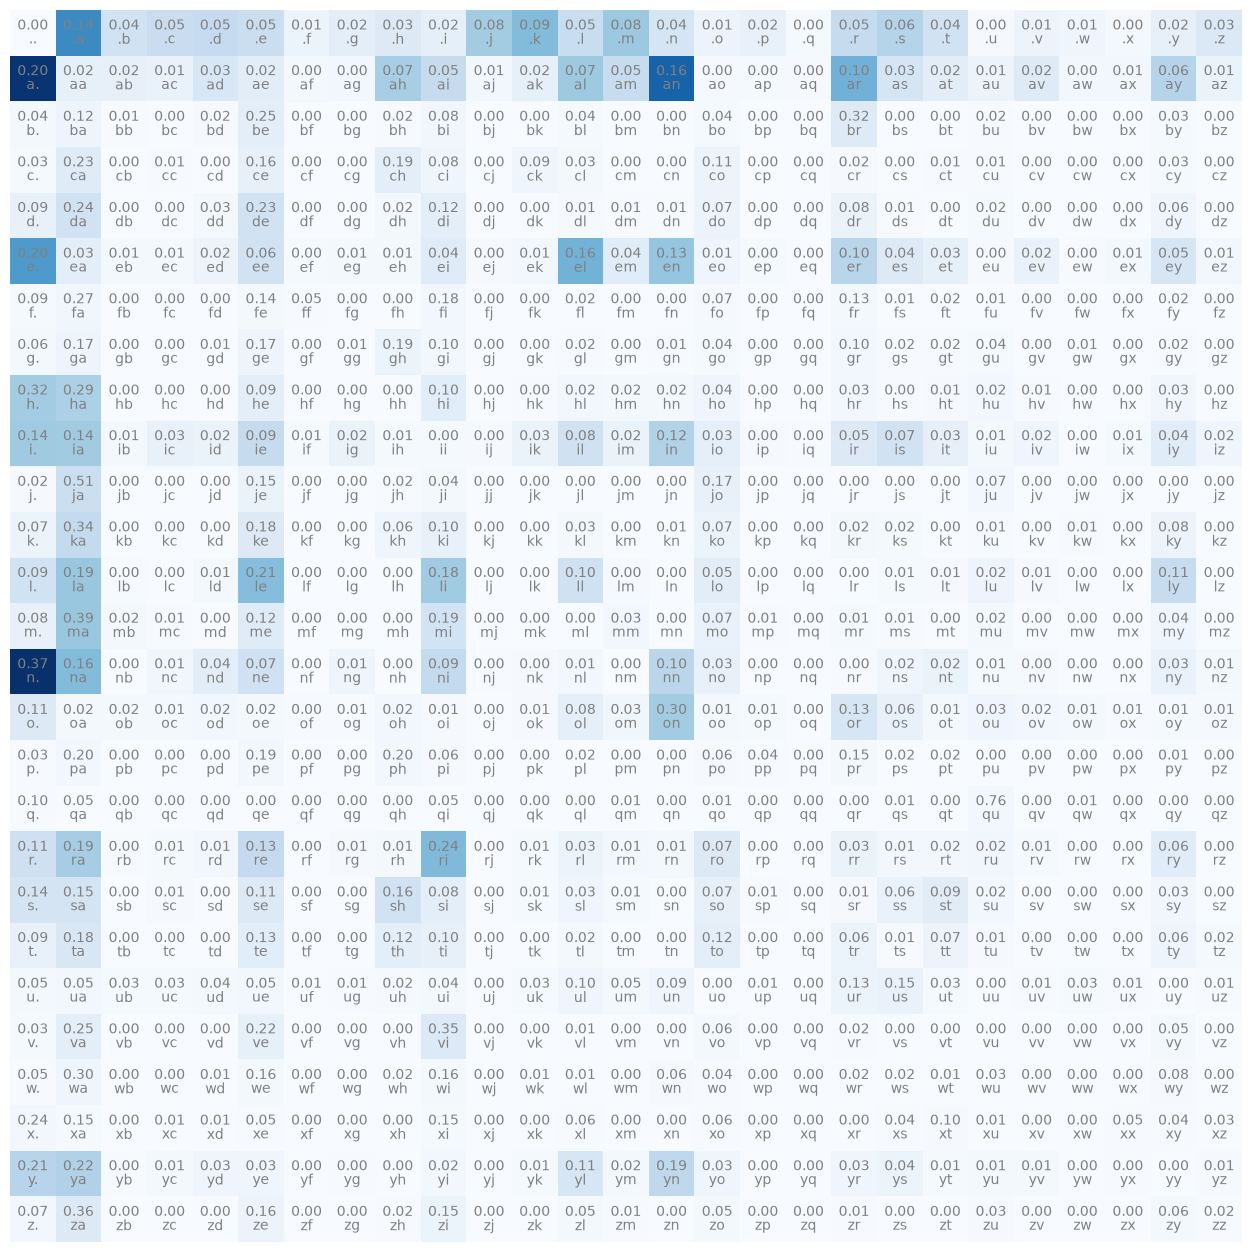

In [14]:
plt.figure(figsize=(16, 16)); plt.imshow(C, cmap="Blues")

for y in range(len(tok2idx)):
    for x in range(len(tok2idx)):
        label = idx2tok[y]+idx2tok[x]
        plt.text(x, y, label, ha="center", va="top", color="gray")
        plt.text(x, y, f"{P[y][x]:.2f}", ha="center", va="bottom", color="gray")
plt.axis('off');

## creating a predictor

In [16]:
g = torch.Generator().manual_seed(2147483647)

for i in range(10):
    ix = 0
    while True: 
        ix = torch.multinomial(P[ix], num_samples=1, replacement=True, generator=g).item()
        print(idx2tok[ix], end="")
        if ix==0: break
    print("")

cexze.
momasurailezitynn.
konimittain.
llayn.
ka.
da.
staiyaubrtthrigotai.
moliellavo.
ke.
teda.


## log loss

how can we summarize the quality of the model?